!pip install pandas

In [92]:
import pandas as pd

In [93]:
df = pd.read_csv('student_performance.csv')

In [94]:
print(df.head())

   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  


In [95]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB
None


In [96]:
print(df.describe())

           student_id  weekly_self_study_hours  attendance_percentage  \
count  1000000.000000           1000000.000000         1000000.000000   
mean    500000.500000                15.029127              84.711046   
std     288675.278933                 6.899431               9.424143   
min          1.000000                 0.000000              50.000000   
25%     250000.750000                10.300000              78.300000   
50%     500000.500000                15.000000              85.000000   
75%     750000.250000                19.700000              91.800000   
max    1000000.000000                40.000000             100.000000   

       class_participation     total_score  
count       1000000.000000  1000000.000000  
mean              5.985203       84.283845  
std               1.956421       15.432969  
min               0.000000        9.400000  
25%               4.700000       73.900000  
50%               6.000000       87.500000  
75%               7.300000 

**Meanings**
- Count: Number of non-missing values
- Mean: Average value
- Std(standard deviation): How spread out the values are. higher std = more variation
- Min: Minimum values
- Max: Maximum values
- Percentiles: Data distribution points
- 25% (Q1): 25% of values are below this
- 50% (Median): Middle value
- 75% (Q3): 75% of values are below this (top 25%)
  
**Input Features**
- Attendance percentage
- Weekly Study Hours
- Class Participations
- Quiz Scores
- Assignment Scores

**Target variable**
- Grade

**Numeric features**
- attendance percentage
- weekly study hours
- quiz scores
- assignment scores

**Need encoding**
- class participation

In [97]:
#importing libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [98]:
#setting style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')

## Check and Remove Duplicates

In [99]:
# Checking for duplicate rows

# Counting duplicate rows (entire row that is exactly the same)
duplicate_count = df.duplicated().sum()
# df.duplicated() returns True/False for each row if its a duplicate
# .sum() counts how many True value (duplicates)

print(f"Number of duplicate rows: {duplicate_count:,}")

# Calculate of duplicate percentage
duplicate_percent = (duplicate_count / len(df)) * 100
print(f"Percentage of duplicates: {duplicate_percent:.2f}%")


# Remove duplicate rows
# duplicates need to be remove because it can become bias to machine learning model

if duplicate_count > 0:
    df_clean = df.drop_duplicates()
    # drop_duplicates() removes rows that are exact copies
    print(f"Removed {duplicate_count:,} duplicate rows")
    print(f"New shape: {df_clean.shape}")
else:
    df_clean = df.copy()
    # .copy() creates a new DataFrame (safety best practice)
    print("No duplicates found")

#save original row count for comparison
original_rows = len(df)
new_rows = len(df_clean)
rows_removed = original_rows - new_rows
print(f"Rows removed due to duplicates: {rows_removed:,}")

Number of duplicate rows: 0
Percentage of duplicates: 0.00%
No duplicates found
Rows removed due to duplicates: 0


There's no duplicate rows in the dataset

## Check and Handle Noise / Unrealistic Values

In [100]:
# Check for unrealistic values

# Define reasonable ranges for each column
# Based on common sense about student data
reasonable_ranges = {
    'weekly_self_study_hours': (0, 40),    # can't study negative hours, max 40 hours per week
    'attendance_percentage': (50, 100),    # Based on min which is 50%
    'class_participation': (0, 10),        # 0 - 10 scale
    'total_score': (0, 100),               # Scores should be 0 - 100%
}

# Check each column for values outside reasonable ranges
print("Values outside reasonable ranges:")

for column, (min_val, max_val) in reasonable_ranges.items():
    if column in df_clean.columns:
        # Count values below minimum
        below_min = (df_clean[column] < min_val).sum()
        # (df_clean[column] < min_val) creates True/False mask
        # .sum() counts True values

        # Count value above maximum
        above_max = (df_clean[column] > max_val).sum()

        if below_min > 0 or above_max > 0:
            print(f" {column}: {below_min:,} below {min_val}, {above_max:,} above {max_val}")

            # Show some example of bad values
            bad_values = df_clean[(df_clean[column] < min_val) | (df_clean[column] > max_val)]
            print(f"  Example of bad values: {bad_values[column].head().tolist()}")


# Clip values
# Preserve data volume (keeps more training examples)
# Less destructive than deleting rows
# Extreme values get brought to reasonable limits

for column, (min_val, max_val) in reasonable_ranges.items():
    if column in df_clean.columns:
        before_min = df_clean[column].min()
        before_max = df_clean[column].max()

        # Clip values to reasonable range
        df_clean[column] = df_clean[column].clip(lower=min_val, upper=max_val)
        # clip() sets values below min_val to min_val
        # and values above max_val to max_val

        after_min = df_clean[column].min()
        after_max = df_clean[column].max()

        if before_min != after_min or before_max != after_max:
            print(f"  {column}:Clipped from [{before_min}, {before_max}] to [{after_min}, {after_max}]")

Values outside reasonable ranges:


The dataset has no unrealistic values

## Encode Target Variable (Grades)

In [101]:
# Check current grade values
print(f"Current grade values: {df_clean['grade'].unique()}")

# Define mapping from letter grades to numbers
# This is called "ordinal encoding" - preserves order (A > B > C > ...)
grade_mapping = {
    'A': 4,
    'B': 3,
    'C': 2,
    'D': 1,
    'F': 0,
}

# Before encoding, check for any unexpected grade values
unexpected_grades = set(df_clean['grade'].unique()) - set(grade_mapping.keys())
if unexpected_grades:
    print(f"Warning: Found unexpected grade values: {unexpected_grades}")
    print("These will become NaN (missing in the numeric version")

# Create new column with numeric grades
df_clean['grade_numeric'] = df_clean['grade'].map(grade_mapping)
# .map() replaces each letter grade with corresponding number

# Check for any missing values after mapping
missing_after_mapping = df_clean['grade_numeric'].isna().sum()
if missing_after_mapping > 0:
    print(f"Warning: {missing_after_mapping:,} rows have grades that couldn't be mapped")
    print("Options: remove these rows or assign a default value")

    # Simple decision: Remove rows with unmappable grades
    df_clean = df_clean.dropna(subset=['grade_numeric'])
    print(f"removed {missing_after_mapping:,} rows with unmappable grades")

# Show distribution of new numeric grades
print("Grade distribution after encoding")
grade_counts = df_clean['grade_numeric'].value_counts().sort_index()
for grade_num, count in grade_counts.items():
    # Convert numeric back to letter for display
    letter_grade = [k for k, v in grade_mapping.items() if v == grade_num][0]
    print(f" {letter_grade} ({grade_num}): {count:,} students ({count/len(df_clean)*100:.1f}%)")

Current grade values: ['A' 'B' 'C' 'D' 'F']
Grade distribution after encoding
 F (0): 6,204 students (0.6%)
 D (1): 44,998 students (4.5%)
 C (2): 141,980 students (14.2%)
 B (3): 258,174 students (25.8%)
 A (4): 548,644 students (54.9%)


## Student Grade Distribution

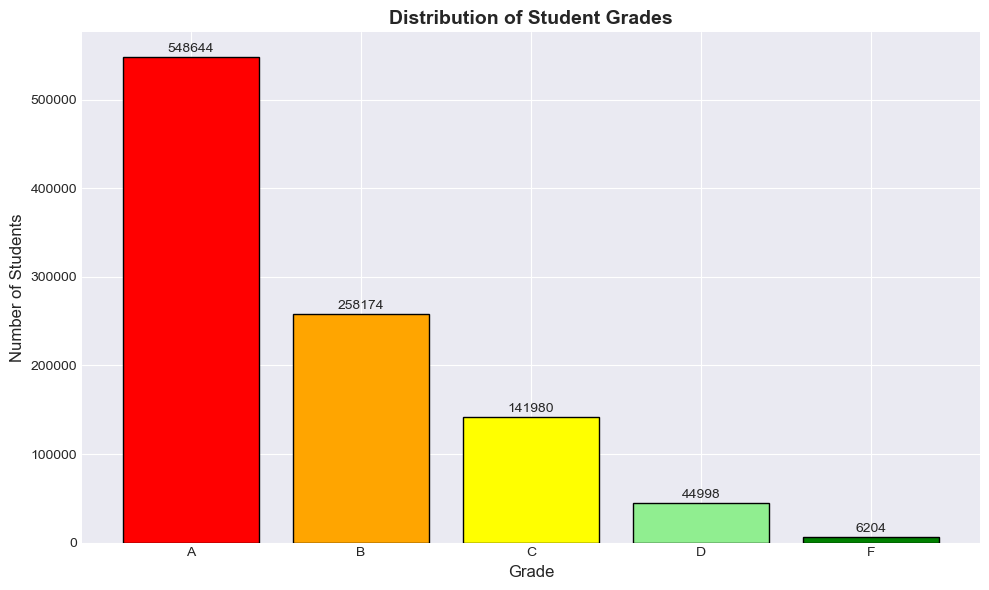

In [103]:
fig, ax = plt.subplots(figsize=(10, 6))

# For categorical data, use bar plot instead of histogram
grade_counts = df['grade'].value_counts().sort_index()
# Gets count of each grade and sorts them

ax.bar(grade_counts.index, grade_counts.values, 
       color=['red', 'orange', 'yellow', 'lightgreen', 'green'],
       edgecolor='black')

ax.set_xlabel('Grade', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Distribution of Student Grades', fontsize=14, fontweight='bold')

# Add count labels on top of bars
for i, (grade, count) in enumerate(grade_counts.items()):
    ax.text(i, count + max(grade_counts.values)*0.01, 
            str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Relationship between Total Score VS Grade

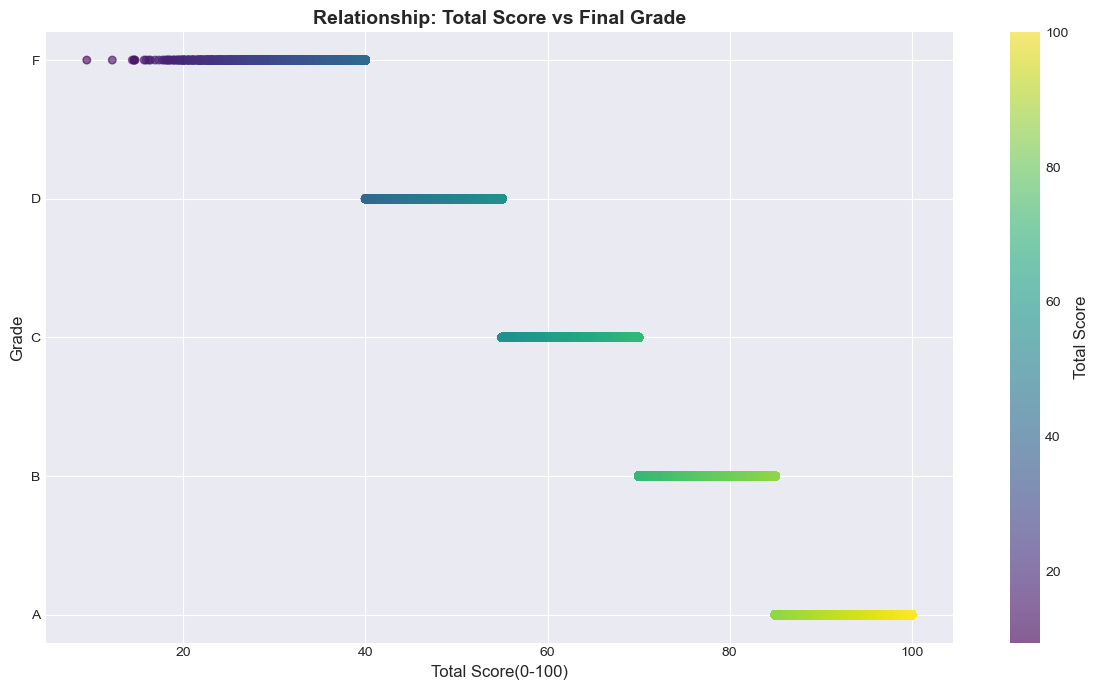

In [104]:
#1. Create figure with larger size
fig, ax = plt.subplots(figsize=(12,7))

#2. Create scatter plot
scatter = ax.scatter(x=df['total_score'], 
                     y=df['grade'],
                     alpha=0.6, 
                     c=df['total_score'],
                     cmap='viridis', 
                     s=30)
#x = total_score (horizontal position)
#y = grade (vertical position)
#alpha=0.6 = makes points slightly transparent
#c=df['total_score'] = color points by their score (creates gradient)
#cmap='viridis' = color map (yellow=low, purple=high)
#s=30 = point size

#3. Add label and title
ax.set_xlabel('Total Score(0-100)', fontsize=12)
ax.set_ylabel('Grade', fontsize=12)
ax.set_title('Relationship: Total Score vs Final Grade',
             fontsize=14, fontweight='bold')

#4. Add colorbar to explain colors
cbar = plt.colorbar(scatter)
cbar.set_label('Total Score', fontsize=12)
#Shows what colors represent which scores

#7. Show plot
plt.tight_layout()
plt.show()

Therefore the higher the total score the higher the Grade is

# Classification

## Features Selection

In [105]:
features = [
    'weekly_self_study_hours',    # How much student studies
    'attendance_percentage',      # How often student attends
    'class_participation'         # How engaged student is
]

# Check if these exist in our data
missing_features = [f for f in features if f not in df_clean.columns]
if missing_features:
    print(f" Missing features: {missing_features}")
    print("Check your dataset columns:", df_clean.columns.tolist())
else:
    print("All required features available!")

# Create X (features) and y (target)
X = df_clean[features].copy()
y = df_clean['grade_numeric'].copy()  # Use numeric grades (0-4)

print(f"\n Feature matrix (X) shape: {X.shape}")
print(f"   Features: {list(X.columns)}")
print(f" Target vector (y) shape: {y.shape}")
print(f"   Target: grade_numeric (0=F, 1=D, 2=C, 3=B, 4=A)")

All required features available!

 Feature matrix (X) shape: (1000000, 3)
   Features: ['weekly_self_study_hours', 'attendance_percentage', 'class_participation']
 Target vector (y) shape: (1000000,)
   Target: grade_numeric (0=F, 1=D, 2=C, 3=B, 4=A)


## Train-Test Split

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Keep same grade distribution
)

print(f"Original dataset: {len(X):,} students")
print(f"Training set (80%): {len(X_train):,} students")
print(f"Testing set (20%): {len(X_test):,} students")

# Show grade distribution
print("\n Grade Distribution:")
print("Training set:")
train_counts = y_train.value_counts().sort_index()
for grade, count in train_counts.items():
    pct = count / len(y_train) * 100
    letter = ['F','D','C','B','A'][grade]
    print(f"  {letter} ({grade}): {count:,} students ({pct:.1f}%)")

Original dataset: 1,000,000 students
Training set (80%): 800,000 students
Testing set (20%): 200,000 students

 Grade Distribution:
Training set:
  F (0): 4,963 students (0.6%)
  D (1): 35,999 students (4.5%)
  C (2): 113,584 students (14.2%)
  B (3): 206,539 students (25.8%)
  A (4): 438,915 students (54.9%)


## Feature Scaling

In [107]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature ranges before scaling:")
for i, feature in enumerate(features):
    print(f"  {feature}: {X_train[feature].min():.1f} to {X_train[feature].max():.1f}")


Feature ranges before scaling:
  weekly_self_study_hours: 0.0 to 40.0
  attendance_percentage: 50.0 to 100.0
  class_participation: 0.0 to 10.0


## Train Logistic Regression (Baseline)

In [108]:
# Create and train model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs'
)

lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Calculate accuracy
lr_train_acc = accuracy_score(y_train, y_train_pred_lr)
lr_test_acc = accuracy_score(y_test, y_test_pred_lr)

print(f"\n Logistic Regression Results:")
print(f"  Training Accuracy: {lr_train_acc:.2%}")
print(f"  Testing Accuracy:  {lr_test_acc:.2%}")
print(f"  Train-Test Gap:    {lr_train_acc - lr_test_acc:.2%}")

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 Logistic Regression Results:
  Training Accuracy: 69.59%
  Testing Accuracy:  69.54%
  Train-Test Gap:    0.05%


## Train Decision Tree (Comparison)

In [109]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,           # Limit depth to prevent overfitting
    min_samples_split=20,
    min_samples_leaf=10
)

dt_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_dt = dt_model.predict(X_train_scaled)
y_test_pred_dt = dt_model.predict(X_test_scaled)

# Calculate accuracy
dt_train_acc = accuracy_score(y_train, y_train_pred_dt)
dt_test_acc = accuracy_score(y_test, y_test_pred_dt)

print(f"\n Decision Tree Results:")
print(f"  Training Accuracy: {dt_train_acc:.2%}")
print(f"  Testing Accuracy:  {dt_test_acc:.2%}")
print(f"  Train-Test Gap:    {dt_train_acc - dt_test_acc:.2%}")


 Decision Tree Results:
  Training Accuracy: 69.56%
  Testing Accuracy:  69.45%
  Train-Test Gap:    0.10%


## Models Comparison

In [110]:
print("\n Accuracy Comparison:")
print(f"{'Model':25} {'Train Acc':12} {'Test Acc':12} {'Gap':10}")
print("-"*60)
print(f"{'Logistic Regression':25} {lr_train_acc:11.2%} {lr_test_acc:11.2%} {lr_train_acc-lr_test_acc:9.2%}")
print(f"{'Decision Tree':25} {dt_train_acc:11.2%} {dt_test_acc:11.2%} {dt_train_acc-dt_test_acc:9.2%}")

# Determine best model
if lr_test_acc > dt_test_acc:
    best_model = "Logistic Regression"
    best_accuracy = lr_test_acc
else:
    best_model = "Decision Tree"
    best_accuracy = dt_test_acc

print(f"\n Best Model: {best_model} ({best_accuracy:.2%} test accuracy)")


 Accuracy Comparison:
Model                     Train Acc    Test Acc     Gap       
------------------------------------------------------------
Logistic Regression            69.59%      69.54%     0.05%
Decision Tree                  69.56%      69.45%     0.10%

 Best Model: Logistic Regression (69.54% test accuracy)


## Confusion Matrix Analysis

In [111]:
# Use the best model for confusion matrix
if best_model == "Logistic Regression":
    best_predictions = y_test_pred_lr
    model_name = "Logistic Regression"
else:
    best_predictions = y_test_pred_dt
    model_name = "Decision Tree"

# Create confusion matrix
cm = confusion_matrix(y_test, best_predictions)

print(f"\nConfusion Matrix for {model_name}:")
print("(Rows: Actual Grades, Columns: Predicted Grades)")
print(f"{'':6} {'Pred F':>7} {'Pred D':>7} {'Pred C':>7} {'Pred B':>7} {'Pred A':>7}")
print("-"*55)

grade_labels = ['F', 'D', 'C', 'B', 'A']
for i, actual_label in enumerate(grade_labels):
    row = f"Act {actual_label}:"
    for j in range(5):
        row += f" {cm[i, j]:>7,}"
    print(row)

# Calculate per-class accuracy
print("\n Per-Class Accuracy:")
for i, grade in enumerate(grade_labels):
    correct = cm[i, i]
    total = cm[i, :].sum()
    accuracy = correct / total if total > 0 else 0
    print(f"  Grade {grade}: {correct:,}/{total:,} correct ({accuracy:.1%})")


Confusion Matrix for Logistic Regression:
(Rows: Actual Grades, Columns: Predicted Grades)
        Pred F  Pred D  Pred C  Pred B  Pred A
-------------------------------------------------------
Act F:       0     855     371      15       0
Act D:       0   3,115   4,846   1,010      28
Act C:       0   2,017  12,837  11,782   1,760
Act B:       0     198   6,460  26,322  18,655
Act A:       0       2     621  12,294  96,812

 Per-Class Accuracy:
  Grade F: 0/1,241 correct (0.0%)
  Grade D: 3,115/8,999 correct (34.6%)
  Grade C: 12,837/28,396 correct (45.2%)
  Grade B: 26,322/51,635 correct (51.0%)
  Grade A: 96,812/109,729 correct (88.2%)


## Feature Importance Analysis


 Logistic Regression Coefficients:
(Positive = increases chance of grade, Negative = decreases chance)
         weekly_self_study_hours  attendance_percentage  class_participation
Grade F                   -4.463                  0.010               -0.007
Grade D                   -2.250                 -0.011               -0.002
Grade C                   -0.084                 -0.001               -0.002
Grade B                    2.067                 -0.001                0.005
Grade A                    4.730                  0.002                0.006

 Decision Tree Feature Importance:
  weekly_self_study_hours: 1.000
  attendance_percentage: 0.000
  class_participation: 0.000


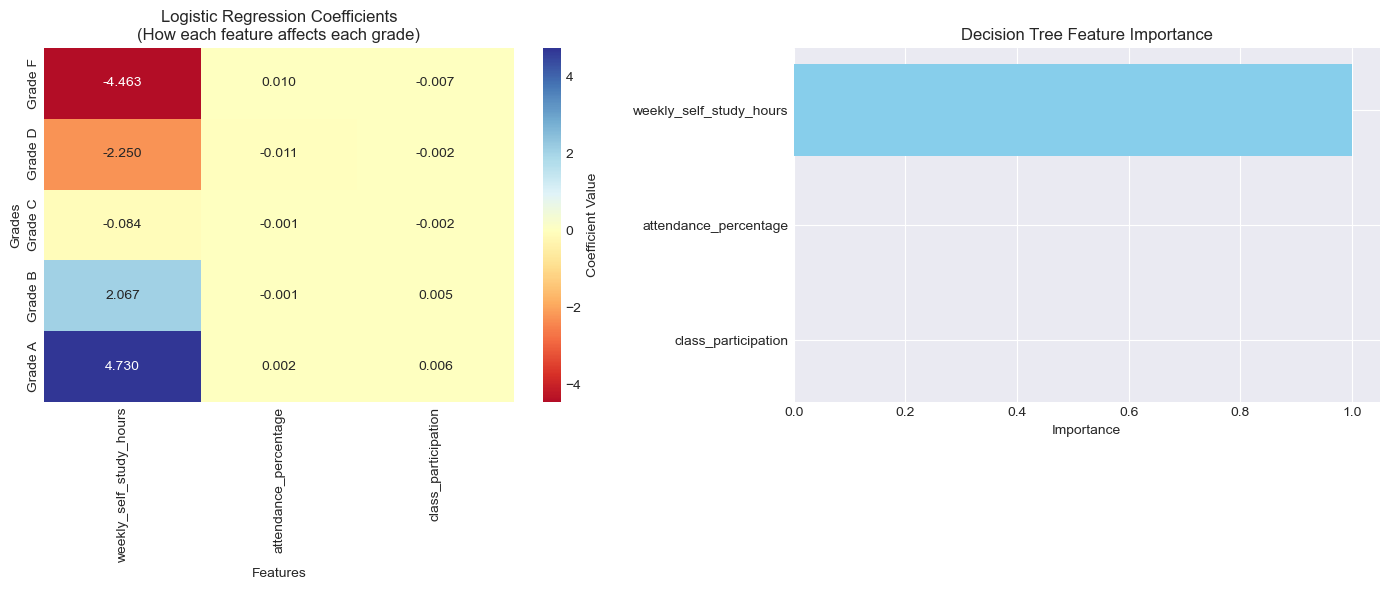

In [112]:
print("\n Logistic Regression Coefficients:")
print("(Positive = increases chance of grade, Negative = decreases chance)")

coef_df = pd.DataFrame(
    lr_model.coef_,
    columns=features,
    index=[f'Grade {g}' for g in grade_labels]
)

print(coef_df.round(3))

print("\n Decision Tree Feature Importance:")
dt_importance = pd.DataFrame({
    'Feature': features,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in dt_importance.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.3f}")

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression coefficients heatmap
sns.heatmap(coef_df, annot=True, fmt='.3f', cmap='RdYlBu', center=0, 
            ax=axes[0], cbar_kws={'label': 'Coefficient Value'})
axes[0].set_title('Logistic Regression Coefficients\n(How each feature affects each grade)', fontsize=12)
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Grades')

# Decision Tree feature importance
axes[1].barh(dt_importance['Feature'], dt_importance['Importance'], color='skyblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Decision Tree Feature Importance', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Saving Models

In [113]:
# Save both models
models_to_save = {
    'logistic_regression': {
        'model': lr_model,
        'scaler': scaler,
        'features': features,
        'accuracy': lr_test_acc
    },
    'decision_tree': {
        'model': dt_model,
        'scaler': scaler,
        'features': features,
        'accuracy': dt_test_acc
    }
}

joblib.dump(models_to_save, 'grade_classification_models.pkl')
print(" Models saved as 'grade_classification_models.pkl'")

print("\n To load and use:")
print("""
import joblib
models = joblib.load('grade_classification_models.pkl')

# Use Logistic Regression
lr = models['logistic_regression']['model']
scaler = models['logistic_regression']['scaler']

# Prepare new data
new_data = pd.DataFrame({
    'weekly_self_study_hours': [20],
    'attendance_percentage': [85],
    'class_participation': [7]
})

# Scale and predict
new_data_scaled = scaler.transform(new_data)
prediction = lr.predict(new_data_scaled)
grade_letter = ['F','D','C','B','A'][prediction[0]]
print(f"Predicted grade: {grade_letter}")
""")

 Models saved as 'grade_classification_models.pkl'

 To load and use:

import joblib
models = joblib.load('grade_classification_models.pkl')

# Use Logistic Regression
lr = models['logistic_regression']['model']
scaler = models['logistic_regression']['scaler']

# Prepare new data
new_data = pd.DataFrame({
    'weekly_self_study_hours': [20],
    'attendance_percentage': [85],
    'class_participation': [7]
})

# Scale and predict
new_data_scaled = scaler.transform(new_data)
prediction = lr.predict(new_data_scaled)
grade_letter = ['F','D','C','B','A'][prediction[0]]
print(f"Predicted grade: {grade_letter}")

